In [2]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../..')

import blurtool

import torch
from PIL import Image

import matplotlib.pyplot as plt
import torchvision
import math
import random

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Nonstationary blur modeling using robust eigenkernels

Abstract: 

### Example 0
figure showing LSV convolution, approximate LSV filter and PCA eigenkernel forward method.

In [65]:
# test approx=False in nonstationary blur with a nondecomposed lattice (parallel forward)

# resizer
resize = torchvision.transforms.Resize(size=(256))

# open test image
test_image=Image.open('../../data/cameraman.tif').convert('L')
test_image=torchvision.transforms.ToTensor()(test_image).squeeze()
test_image=resize(test_image.unsqueeze(0)).squeeze()
img_shape=test_image.shape
print('img_shape=',img_shape)

# define lattice
kernel_shape=(32,32)
lattice_pars={'ax':0.07,'ay':0.07,'bx':0.4,'by':0.3,'gamma_x':1,'gamma_y':1} # 0.07
lat=blurtool.RotGaussian(img_shape,kernel_shape,lattice_pars)
print('kernel_shape=',kernel_shape)

# sample original lattice
sampled_shape=(8,8)
sampled_lat=lat.sample(sampled_shape)
print('sampled_shape=',sampled_shape)
r=15
pars_pca={'r':r}
pca_lat=blurtool.DecomposeLattice(sampled_lat,img_shape,mode='pca',decompose_pars=pars_pca)

# lsvc blur
rgblur_lsvc=blurtool.NonstationaryBlur(lat,approx=False)
blurred_test_image_lsvc=rgblur_lsvc.forward(test_image,n_pool=8,debug=True)
print('computed lsvc blurred image')

# approx filter blur
rgblur=blurtool.NonstationaryBlur(lat)
blurred_test_image=rgblur.forward(test_image,n_pool=8)
print('computed approx filter blurred image')

# pca lat blur 
pca_blur=blurtool.NonstationaryBlur(pca_lat)
blurred_test_image_pca=pca_blur.forward(test_image)
print('computed pca lat blurred image')

# # results
fig,ax=plt.subplots(1,4,figsize=(15,15))

ax[0].axis('off')
ax[0].imshow(test_image,cmap='gray')
ax[1].axis('off')
ax[1].imshow(blurred_test_image_lsvc,cmap='gray')
ax[2].axis('off')
ax[2].imshow(blurred_test_image,cmap='gray')
ax[3].axis('off')
ax[3].imshow(blurred_test_image_pca,cmap='gray')
plt.show()

print('-------------------------------------------------------')
print('forward_timer_lsvc=',rgblur_lsvc.forward_timer)
print('forward_timer_approxfilter=',rgblur.forward_timer)
print('forward_timer_pca=',pca_blur.forward_timer)
print('-------------------------------------------------------')
print('PSNR(blurred_lsvc,blurred_approxfilter)=',blurtool.psnr(blurred_test_image_lsvc,blurred_test_image))
print('PSNR(blurred_approxfilter,blurred_pca)=',blurtool.psnr(blurred_test_image,blurred_test_image_pca))
print('PSNR(blurred_lsvc,blurred_pca)=',blurtool.psnr(blurred_test_image_lsvc,blurred_test_image_pca))
print('-------------------------------------------------------')
print('SSIM(blurred_lsvc,blurred_approxfilter)=',blurtool.ssim(blurred_test_image_lsvc,blurred_test_image))
print('SSIM(blurred_approxfilter,blurred_pca)=',blurtool.ssim(blurred_test_image,blurred_test_image_pca))
print('SSIM(blurred_lsvc,blurred_pca)=',blurtool.ssim(blurred_test_image_lsvc,blurred_test_image_pca))

# save images
plt.imshow(test_image,cmap='gray')
plt.axis('off')
plt.savefig('ex0_x.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

plt.imshow(blurred_test_image_lsvc,cmap='gray')
plt.axis('off')
plt.savefig('ex0_y_lvsc.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

plt.imshow(blurred_test_image,cmap='gray')
plt.axis('off')
plt.savefig('ex0_y_approxfilter.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

plt.imshow(blurred_test_image_pca,cmap='gray')
plt.axis('off')
plt.savefig('ex0_y_pca.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

img_shape= torch.Size([256, 256])
kernel_shape= (32, 32)
sampled_shape= (8, 8)


Process SpawnPoolWorker-150:
Process SpawnPoolWorker-151:
Process SpawnPoolWorker-147:
Process SpawnPoolWorker-152:
Process SpawnPoolWorker-148:
Process SpawnPoolWorker-145:
Process SpawnPoolWorker-146:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/home/mauro/miniconda3/envs/blurtool/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/home/mauro/miniconda3/envs/blurtool/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/home/mauro/miniconda3/envs/blurtool/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/home/mauro/miniconda3/envs/blurtool/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/home/mauro/miniconda3/envs/blurtool/lib/python3.10/multiprocessing/process.py", line 108, in run
    

KeyboardInterrupt: 

## Numerical experiments

### Example 1 (salt and pepper corrupted PSF)

img_shape= torch.Size([256, 256])
kernel_shape= (32, 32)
mu= tensor(166.9919) . lamb= 0.09 . rank= 0


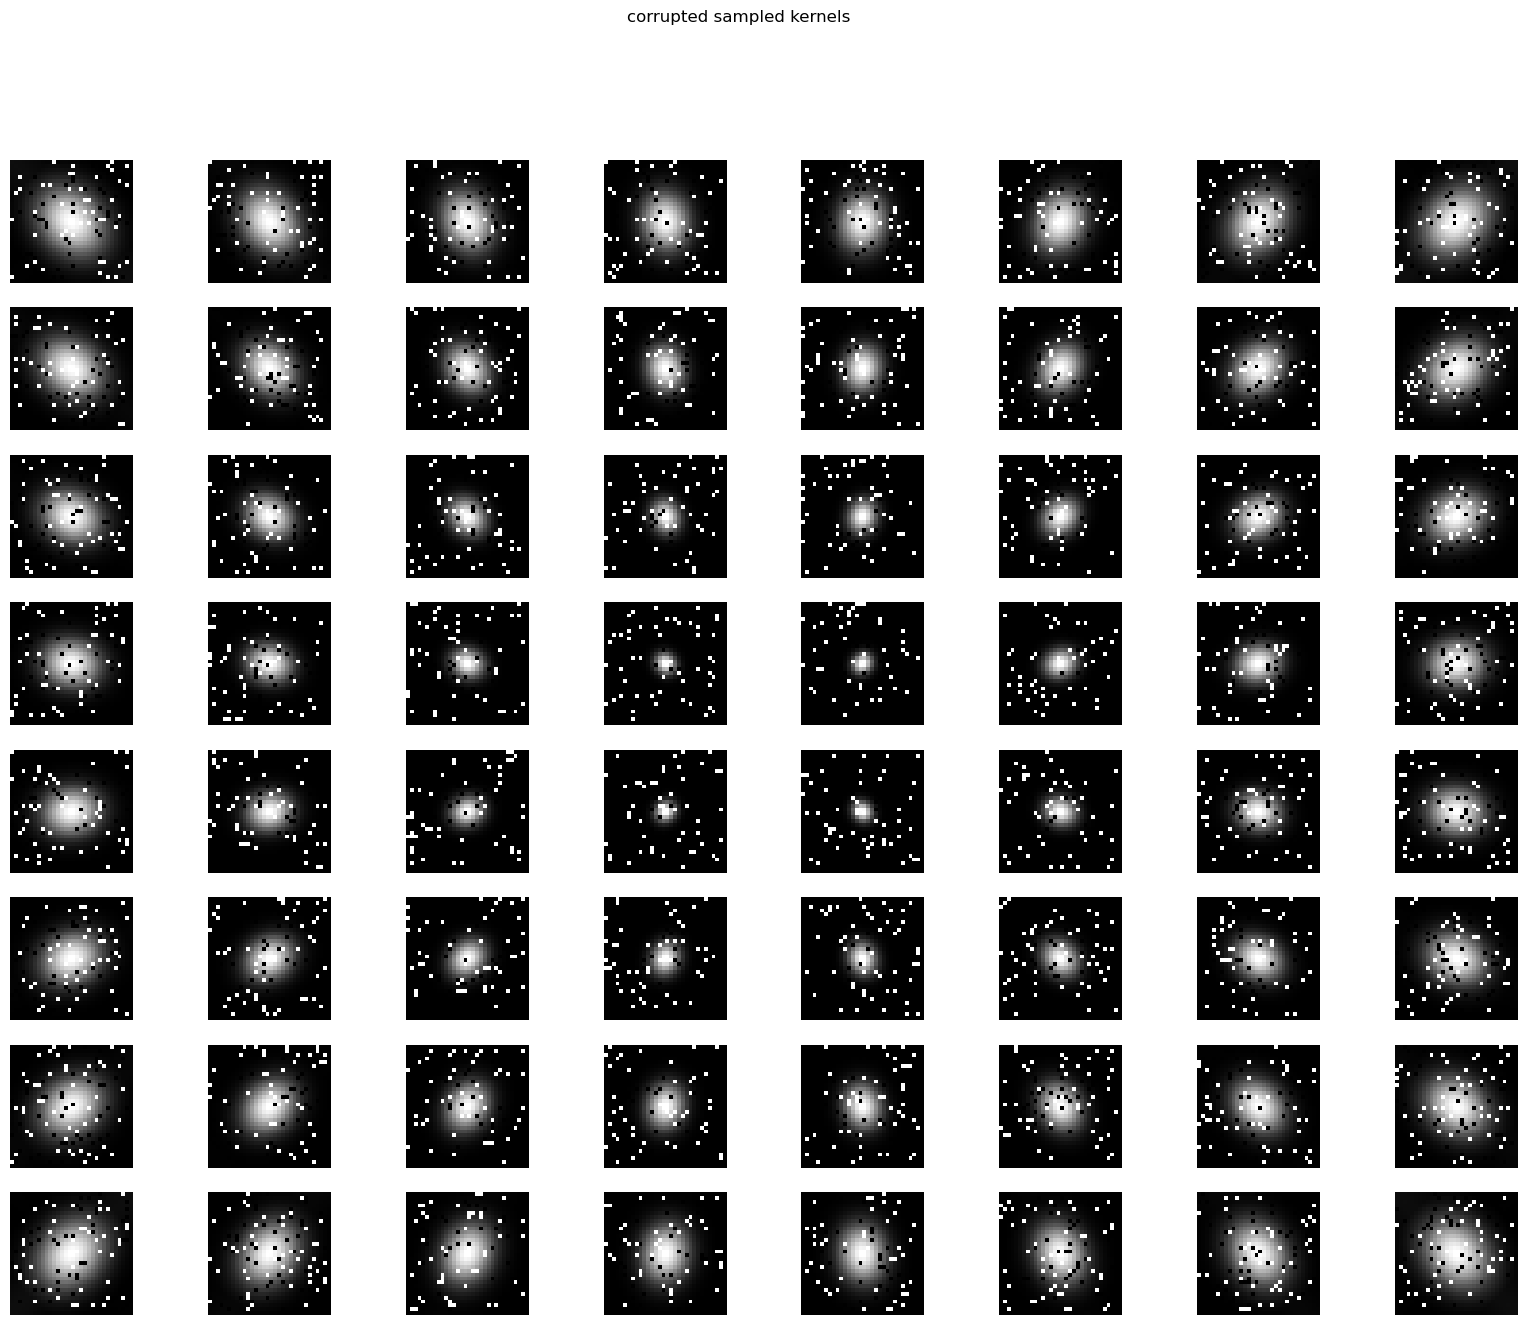

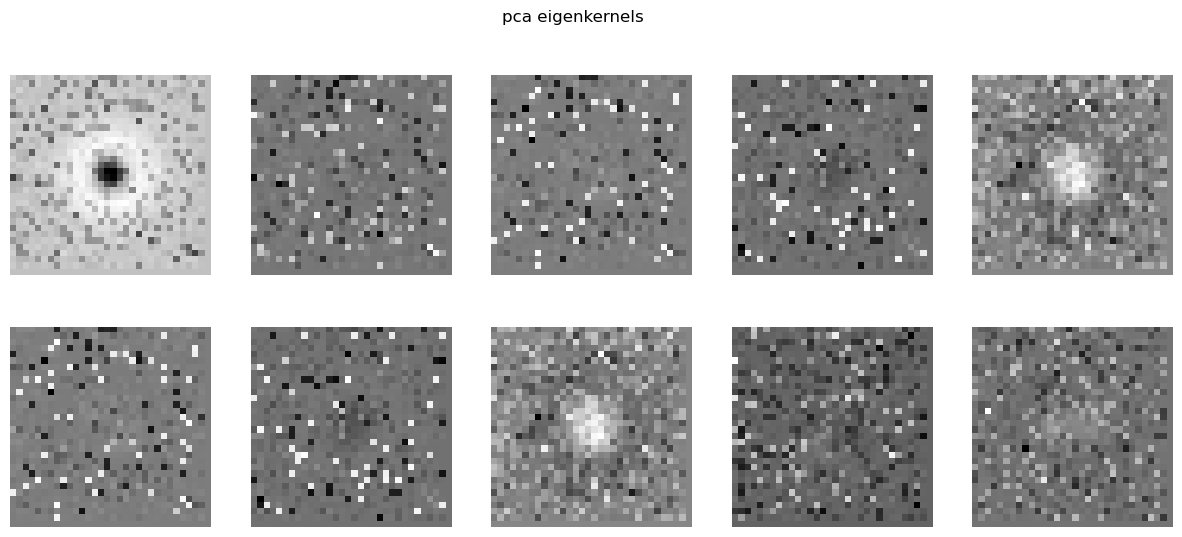

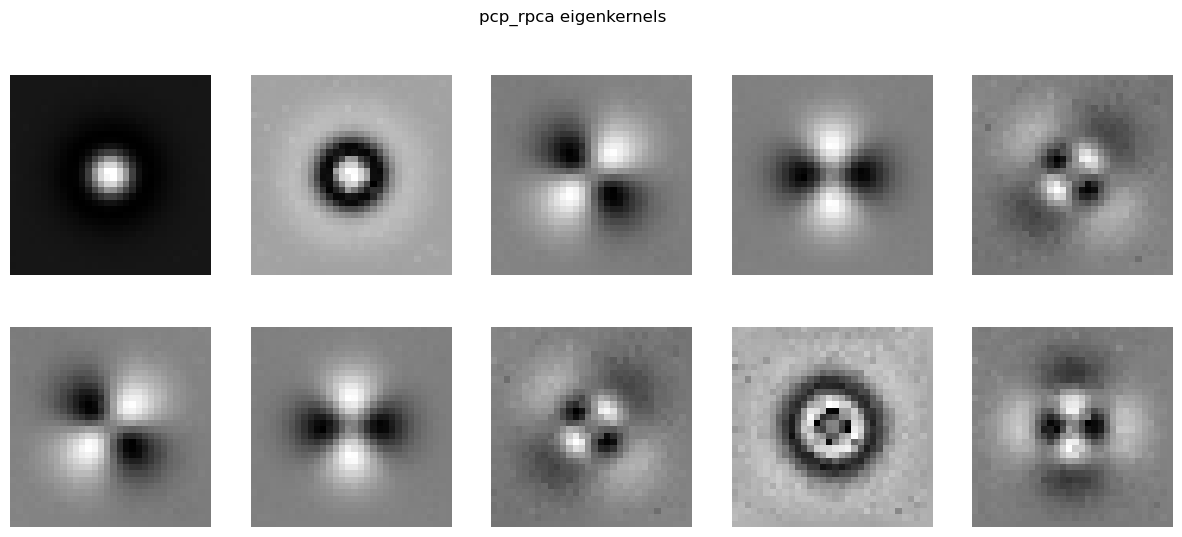

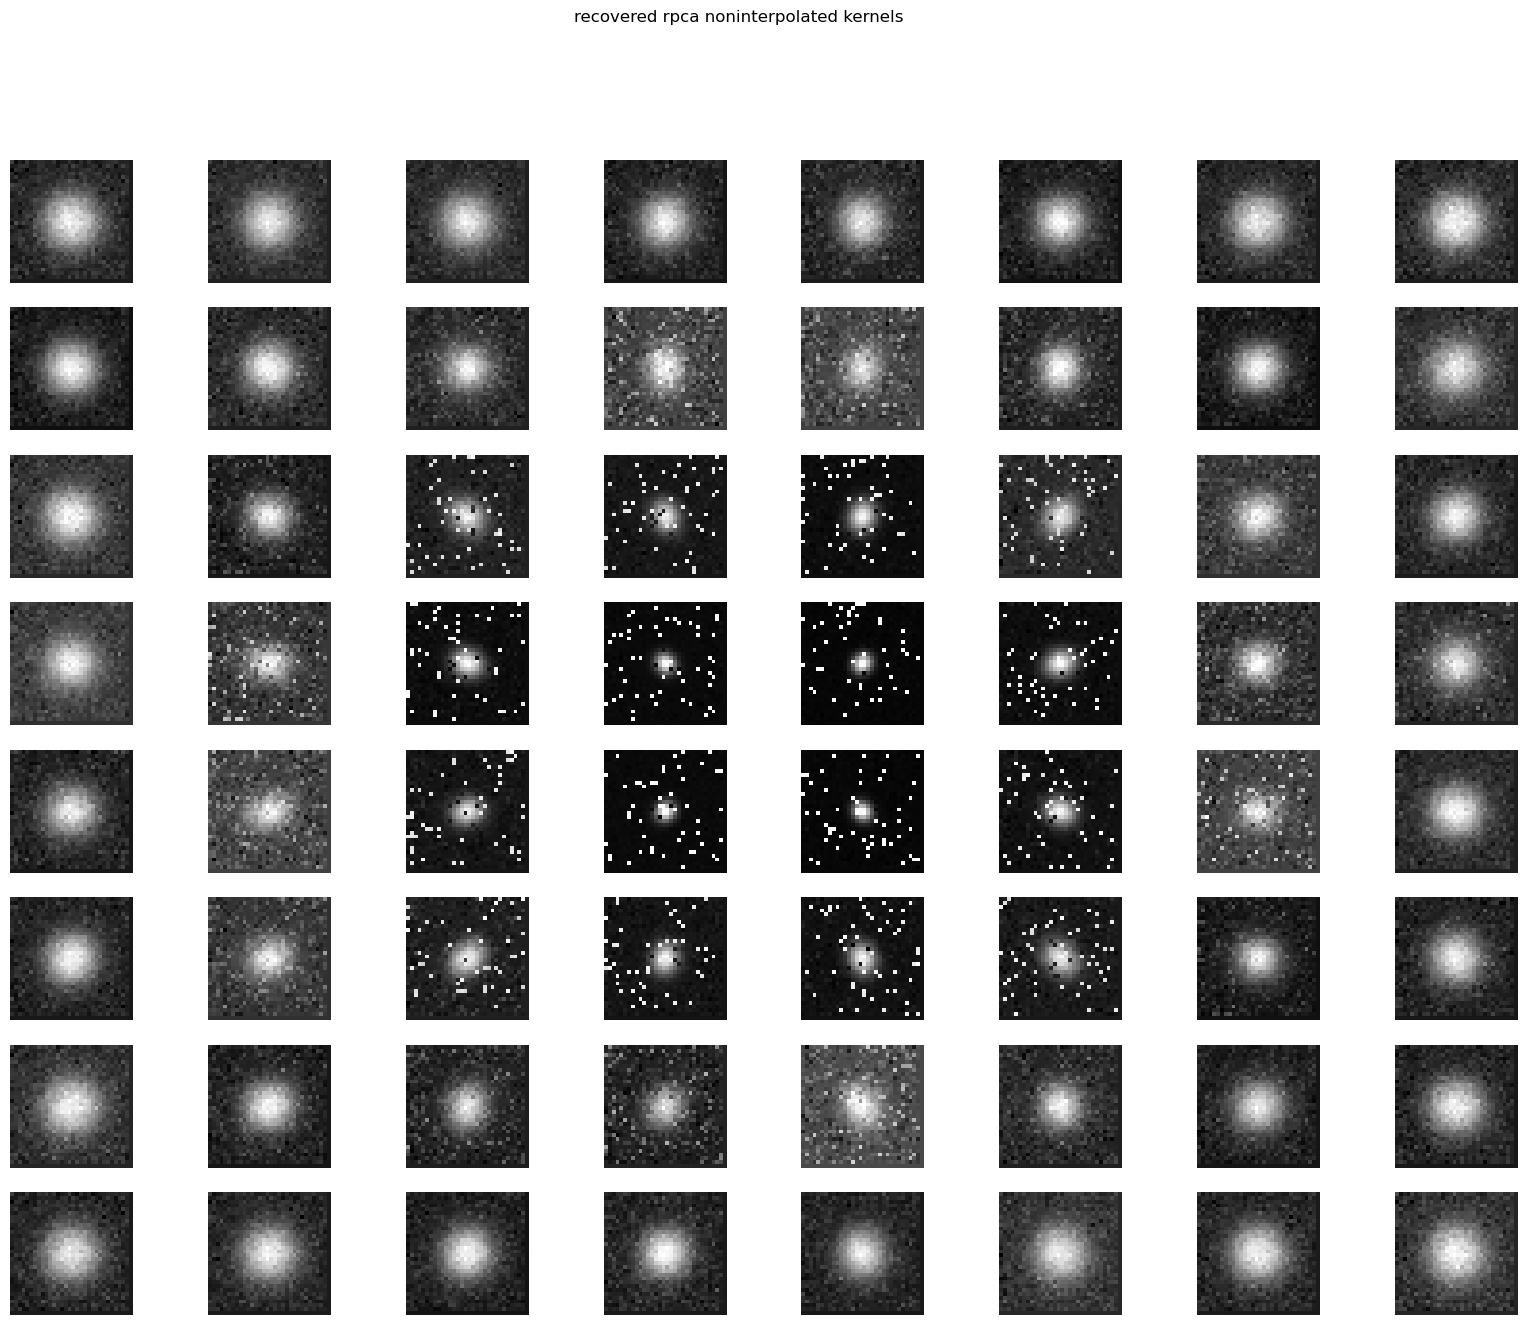

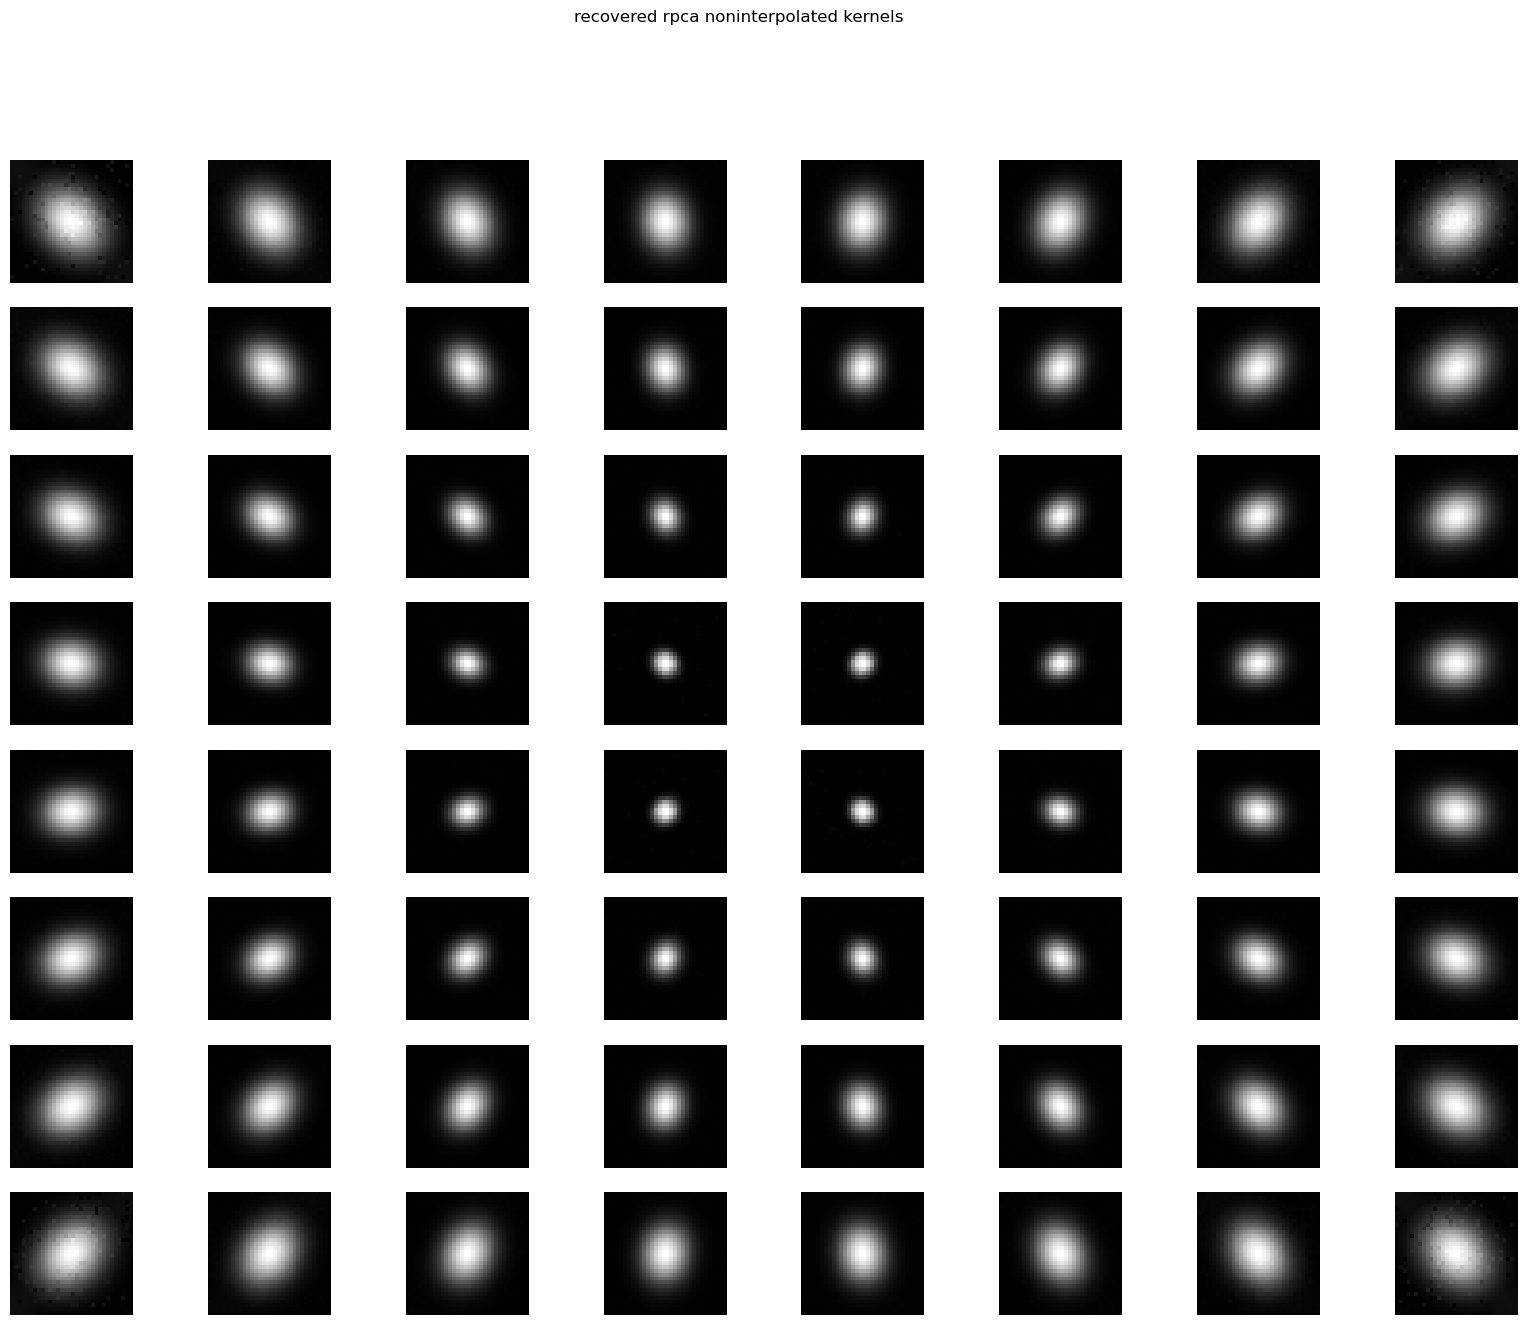

In [82]:
# blurring a test image with a lattice of kernels versus the sampled-decomposed version of the same lattice

# resizer
resize = torchvision.transforms.Resize(size=(256))

# open test image
test_image=Image.open('../../data/cameraman.tif').convert('L')
# test_image=Image.open('../../data/ccia/47.gif').convert('L')
test_image=torchvision.transforms.ToTensor()(test_image).squeeze().double()

# resize and normalize
test_image=resize(test_image.unsqueeze(0)).squeeze()
test_image=blurtool.normalize_minmax(test_image)
img_shape=test_image.shape
print('img_shape=',img_shape)


# define lattice
kernel_shape=(32,32)
lattice_pars={'ax':0.07,'ay':0.07,'bx':0.4,'by':0.3,'gamma_x':1,'gamma_y':1}
lat=blurtool.RotGaussian(img_shape,kernel_shape,lattice_pars)
print('kernel_shape=',kernel_shape)

# sample original lattice
sampled_shape=(8,8)
sampled_lat=lat.sample(sampled_shape)

# # find out the greatest salt and lowest pepper values
# salt_val=-10000
# pepper_val=10000
# for key in sampled_lat.kernels:
#     if torch.max(sampled_lat.kernels[key].psf_data)>salt_val:
#         salt_val=torch.max(sampled_lat.kernels[key].psf_data)
#     if torch.min(sampled_lat.kernels[key].psf_data)<pepper_val:
#         pepper_val=torch.min(sampled_lat.kernels[key].psf_data)

# use individual salt and pepper values
salt_val=None
pepper_val=None

# corrupt sampled kernels with salt and pepper noise
for key in sampled_lat.kernels:
    sampled_lat.kernels[key].psf_data=blurtool.spnoise(sampled_lat.kernels[key].psf_data,amount=0.1,salt_val=salt_val,pepper_val=pepper_val) # 0.2 # 0.1
    
# decompose sampled lattice
r=20
pars_pca={'r':r}
pars_rpca={'lamb':0.09,'r':r,'tol':1e-20,'max_iter':500,'debug':False} # 0.1 - 27x27 or 32x32
# pars_rpca={'r':r,'debug':False}
pca_lat=blurtool.DecomposeLattice(sampled_lat,img_shape,mode='pca',decompose_pars=pars_pca)
rpca_lat=blurtool.DecomposeLattice(sampled_lat,img_shape,mode='pcp_rpca',decompose_pars=pars_rpca)


# plot corrupted sampled kernels
fig,ax=plt.subplots(sampled_shape[0],sampled_shape[1],figsize=(20,15))
fig.suptitle('corrupted sampled kernels')
for i in range(sampled_shape[0]):
    for j in range(sampled_shape[1]):
        ax[i,j].axis('off')
        ax[i,j].imshow(sampled_lat.kernel([i,j])(),cmap='gray')
plt.show()

# plot pca kernels
n_rows=2
n_columns=5
fig,ax=plt.subplots(n_rows,n_columns,figsize=(15,6))
fig.suptitle('pca eigenkernels')
for i in range(n_rows):
    for j in range(n_columns):
        ax[i,j].axis('off')
        ax[i,j].imshow(pca_lat.eigenkernels[int(1+i*n_rows+j)](),cmap='gray')
plt.show()

# plot pcp_rpca kernels
n_rows=2
n_columns=5
fig,ax=plt.subplots(n_rows,n_columns,figsize=(15,6))
fig.suptitle('pcp_rpca eigenkernels')
for i in range(n_rows):
    for j in range(n_columns):
        ax[i,j].axis('off')
        ax[i,j].imshow(rpca_lat.eigenkernels[int(1+i*n_rows+j)](),cmap='gray')
plt.show()

# plot reconsctructed pca noninterpolated kernels
fig,ax=plt.subplots(sampled_shape[0],sampled_shape[1],figsize=(20,15))
fig.suptitle('recovered rpca noninterpolated kernels')
for i in range(sampled_shape[0]):
    for j in range(sampled_shape[1]):
        ax[i,j].axis('off')
        ax[i,j].imshow(pca_lat.noninterpolated_kernel([i,j])(),cmap='gray')
plt.show()

# plot reconsctructed rpca noninterpolated kernels
fig,ax=plt.subplots(sampled_shape[0],sampled_shape[1],figsize=(20,15))
fig.suptitle('recovered rpca noninterpolated kernels')
for i in range(sampled_shape[0]):
    for j in range(sampled_shape[1]):
        ax[i,j].axis('off')
        ax[i,j].imshow(rpca_lat.noninterpolated_kernel([i,j])(),cmap='gray')
plt.show()

### scree plots

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


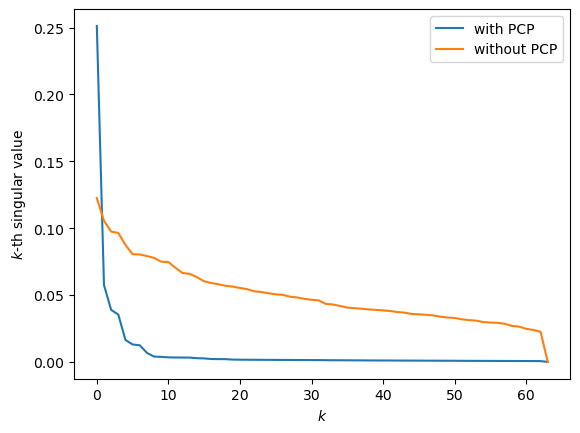

In [85]:
plt.plot(rpca_lat.singularvalues[1:],label='with PCP')
plt.plot(pca_lat.singularvalues[1:],label='without PCP')
plt.ylabel(r'$k$-th singular value')
plt.xlabel(r'$k$')
plt.legend();
plt.savefig('res0_singular_values.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

In [86]:
# max(kernel_shape8*8)

In [87]:
1/math.sqrt(kernel_shape[0]*kernel_shape[1])

0.03125

In [88]:
# plt.imshow(sampled_lat.kernel((0,0))())

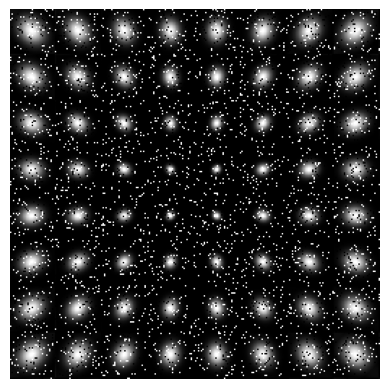

In [89]:
resampled_lat=sampled_lat.sample(sampled_shape,normalize=True,normalize_mode='minmax')
view_sampled_lat=blurtool.InterpolateLattice(resampled_lat,img_shape,mode='zero_dummy')
plt.imshow(view_sampled_lat.grid(sampled_shape,blur=True),cmap='gray')
plt.axis('off')
plt.savefig('res0_hplusnoise.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

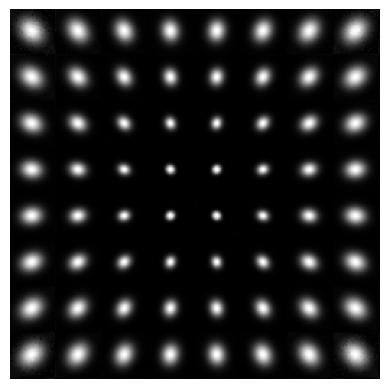

In [90]:
plt.imshow(rpca_lat.grid((8,8),blur=True,normalize=True),cmap='gray')
plt.axis('off')
plt.savefig('res0_hhat_rpca.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

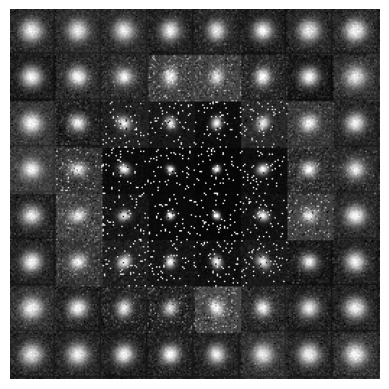

In [91]:
plt.imshow(pca_lat.grid((8,8),blur=True,normalize=True),cmap='gray')
plt.axis('off')
plt.savefig('res0_hhat_pca.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

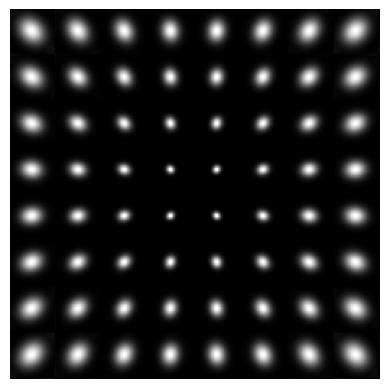

In [92]:
plt.imshow(lat.grid((8,8),blur=True,normalize=True),cmap='gray')
plt.axis('off')
plt.savefig('res0_h.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

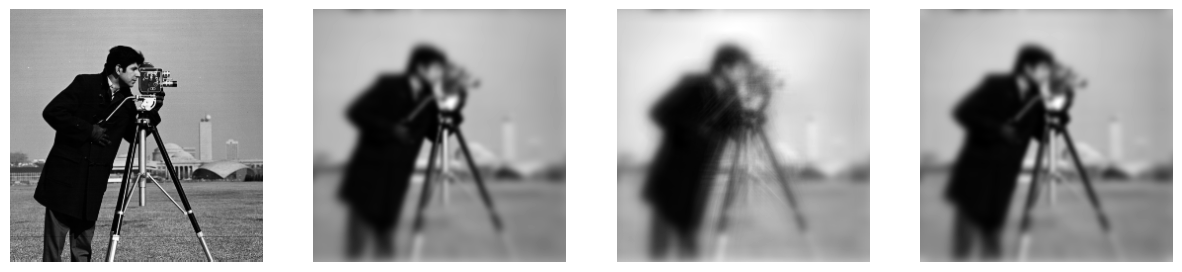

blur.forward_timer= 329.8210027589812
pca_blur.forward_timer= 0.05395536602009088
rpca_blur.forward_timer= 0.052658307016827166
PSNR(blurred,pca_blurred)= tensor(18.4861, dtype=torch.float64)
PSNR(blurred,rpca_blurred)= tensor(37.2422, dtype=torch.float64)
SSIM(blurred,pca_blurred)= tensor(0.9408, dtype=torch.float64)
SSIM(blurred,rpca_blurred)= tensor(0.9974, dtype=torch.float64)


In [83]:
## blur a test image 

# define blurs and apply
# blur=blurtool.NonstationaryBlur(lat)
pca_blur=blurtool.NonstationaryBlur(pca_lat)
rpca_blur=blurtool.NonstationaryBlur(rpca_lat)

# blurred_test_image=blur.forward(test_image,n_pool=8,debug=True)
pca_blurred_test_image=pca_blur.forward(test_image,debug=False)
rpca_blurred_test_image=rpca_blur.forward(test_image,debug=False)

fig,ax=plt.subplots(1,4,figsize=(15,15))

ax[0].axis('off')
ax[0].imshow(test_image,cmap='gray')
ax[1].axis('off')
ax[1].imshow(blurred_test_image,cmap='gray')
ax[2].axis('off')
ax[2].imshow(pca_blurred_test_image,cmap='gray')
ax[3].axis('off')
ax[3].imshow(rpca_blurred_test_image,cmap='gray')
plt.show()


# print forward timers
print('blur.forward_timer=',blur.forward_timer)
print('pca_blur.forward_timer=',pca_blur.forward_timer)
print('rpca_blur.forward_timer=',rpca_blur.forward_timer)

# print psnr
print('PSNR(blurred,pca_blurred)=',blurtool.psnr(blurred_test_image,pca_blurred_test_image))
print('PSNR(blurred,rpca_blurred)=',blurtool.psnr(blurred_test_image,rpca_blurred_test_image))
print('SSIM(blurred,pca_blurred)=',blurtool.ssim(blurred_test_image,pca_blurred_test_image))
print('SSIM(blurred,rpca_blurred)=',blurtool.ssim(blurred_test_image,rpca_blurred_test_image))


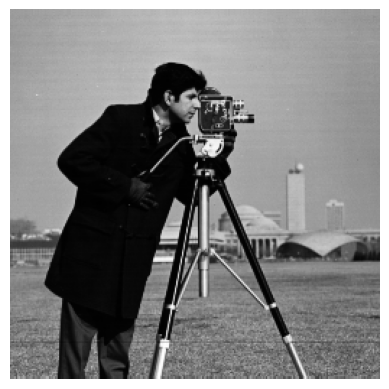

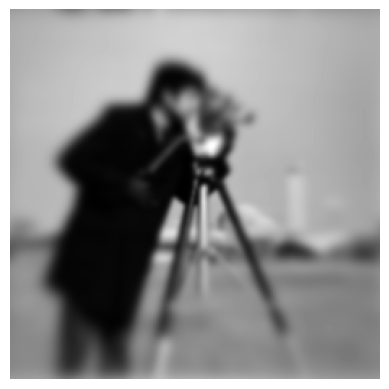

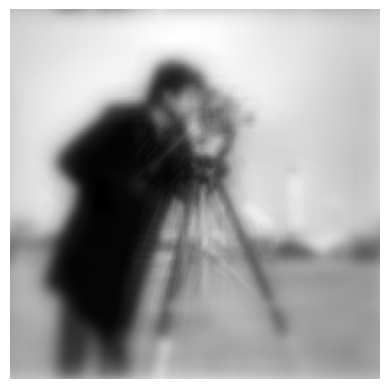

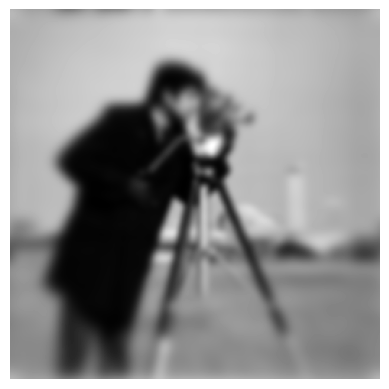

In [84]:
# save images
plt.imshow(test_image,cmap='gray')
plt.axis('off')
plt.savefig('res0_x.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

plt.imshow(blurred_test_image,cmap='gray')
plt.axis('off')
plt.savefig('res0_y.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

plt.imshow(pca_blurred_test_image,cmap='gray')
plt.axis('off')
plt.savefig('res0_ypca.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

plt.imshow(rpca_blurred_test_image,cmap='gray')
plt.axis('off')
plt.savefig('res0_yrpca.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()